# Taller 1 — Machine Learning Applied
## Caso de Clasificación: Diagnóstico de Recurrencia de Cáncer Diferenciado de Tiroides

**Dataset:** [Thyroid Disease Data (Kaggle)](https://www.kaggle.com/datasets/jainaru/thyroid-disease-data/data)

Este notebook desarrolla el ciclo completo de un proyecto de Machine Learning supervisado —limpieza, preprocesamiento, partición train/validation/test, pipelines con `ColumnTransformer`, entrenamiento y comparación de modelos, y validación cruzada con optimización de hiperparámetros— sobre un problema de clasificación binaria en el dominio clínico.

# Fase 1 — EDA, limpieza y preprocesamiento

## 1. Problema de negocio/salud y variable objetivo

**Contexto clínico.** El dataset recoge el seguimiento clínico de pacientes tratados por **carcinoma diferenciado de tiroides** (papilar, folicular, células de Hürthle o micropapilar), la variante más común y de mejor pronóstico del cáncer de tiroides. Aun con tratamiento (cirugía + eventual yodo radiactivo), una fracción de los pacientes presenta **recurrencia** de la enfermedad durante el seguimiento.

**Problema de negocio/salud.** Anticipar qué pacientes tienen mayor probabilidad de recurrencia permite al equipo médico decidir la intensidad del seguimiento (frecuencia de controles, estudios de imagen, umbral para reintervenir) y ajustar la agresividad del tratamiento inicial. Un modelo predictivo de apoyo clínico no reemplaza el juicio médico, pero puede priorizar recursos de seguimiento hacia los pacientes de mayor riesgo.

**Variable objetivo (target):** `Recurred` — binaria, `Yes` (el cáncer recurrió) / `No` (no ha recurrido). Es la variable que buscamos predecir a partir de las características demográficas, clínicas, patológicas y de estadificación (TNM) del paciente al momento del diagnóstico/tratamiento inicial.

In [3]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, RobustScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay, classification_report)

RANDOM_STATE = 42
sns.set_style("whitegrid")
pd.set_option("display.max_columns", 50)
plt.rcParams["figure.dpi"] = 100


In [4]:
df = pd.read_csv("data/Thyroid_Diff.csv")
print("Dataset de Thyroid Disease cargado exitosamente.")
print("\n--- head() ---")
display(df.head())
print("\n--- tail() ---")
display(df.tail())
print("\n--- shape ---")
print(df.shape)
print("\n--- info() ---")
df.info()


Dataset de Thyroid Disease cargado exitosamente.

--- head() ---


,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Excellent,No



--- tail() ---


,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
378,72,M,Yes,Yes,Yes,Euthyroid,Single nodular goiter-right,Right,Papillary,Uni-Focal,High,T4b,N1b,M1,IVB,Biochemical Incomplete,Yes
379,81,M,Yes,No,Yes,Euthyroid,Multinodular goiter,Extensive,Papillary,Multi-Focal,High,T4b,N1b,M1,IVB,Structural Incomplete,Yes
380,72,M,Yes,Yes,No,Euthyroid,Multinodular goiter,Bilateral,Papillary,Multi-Focal,High,T4b,N1b,M1,IVB,Structural Incomplete,Yes
381,61,M,Yes,Yes,Yes,Clinical Hyperthyroidism,Multinodular goiter,Extensive,Hurthel cell,Multi-Focal,High,T4b,N1b,M0,IVA,Structural Incomplete,Yes
382,67,M,Yes,No,No,Euthyroid,Multinodular goiter,Bilateral,Papillary,Multi-Focal,High,T4b,N1b,M0,IVA,Structural Incomplete,Yes



--- shape ---
(383, 17)

--- info() ---
<class 'pandas.DataFrame'>
RangeIndex: 383 entries, 0 to 382
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Age                   383 non-null    int64
 1   Gender                383 non-null    str  
 2   Smoking               383 non-null    str  
 3   Hx Smoking            383 non-null    str  
 4   Hx Radiothreapy       383 non-null    str  
 5   Thyroid Function      383 non-null    str  
 6   Physical Examination  383 non-null    str  
 7   Adenopathy            383 non-null    str  
 8   Pathology             383 non-null    str  
 9   Focality              383 non-null    str  
 10  Risk                  383 non-null    str  
 11  T                     383 non-null    str  
 12  N                     383 non-null    str  
 13  M                     383 non-null    str  
 14  Stage                 383 non-null    str  
 15  Response              383 n

**Diccionario de datos**

| Columna | Tipo esperado | Significado |
|---|---|---|
| `Age` | numérica continua | Edad del paciente (años) |
| `Gender` | categórica nominal binaria | Sexo del paciente (F/M) |
| `Smoking` | categórica nominal binaria | Fumador activo (Yes/No) |
| `Hx Smoking` | categórica nominal binaria | Historial de tabaquismo previo (Yes/No) |
| `Hx Radiothreapy` | categórica nominal binaria | Historial de radioterapia previa en cabeza/cuello (Yes/No) |
| `Thyroid Function` | categórica nominal | Estado funcional tiroideo al diagnóstico (eu-, hipo- o hipertiroidismo, clínico o subclínico) |
| `Physical Examination` | categórica nominal | Hallazgo del examen físico tiroideo (bocio nodular/difuso, normal) |
| `Adenopathy` | categórica nominal | Localización de ganglios linfáticos afectados |
| `Pathology` | categórica nominal | Subtipo histopatológico del carcinoma |
| `Focality` | categórica nominal binaria | Tumor unifocal o multifocal |
| `Risk` | categórica **ordinal** | Categoría de riesgo de recurrencia (Low < Intermediate < High) |
| `T` | categórica **ordinal** | Estadio del tumor primario (clasificación TNM) |
| `N` | categórica **ordinal** | Estadio de compromiso ganglionar regional (TNM) |
| `M` | categórica nominal binaria | Metástasis a distancia (M0/M1) |
| `Stage` | categórica **ordinal** | Estadio clínico global (I < II < III < IVA < IVB) |
| `Response` | categórica **ordinal** | Respuesta al tratamiento inicial |
| `Recurred` | categórica nominal binaria — **TARGET** | Recurrencia del cáncer (Yes/No) |

El dataset tiene 383 filas y 17 columnas, sin valores nulos declarados por pandas (`info()` reporta 383 non-null en todas las columnas) y una sola variable numérica continua (`Age`); el resto son variables categóricas de tipo `object`.

## 2-3. Estadísticos descriptivos (`describe()`) e interpretación

In [5]:
display(df.describe())
display(df['Age'].describe())


,Age
count,383.000000
mean,40.866841
std,15.134494
min,15.000000
25%,29.000000
50%,37.000000
75%,51.000000
max,82.000000


count    383.000000
mean      40.866841
std       15.134494
min       15.000000
25%       29.000000
50%       37.000000
75%       51.000000
max       82.000000
Name: Age, dtype: float64

**Interpretación de al menos 3 estadísticos (columna `Age`, única numérica continua):**

- **Media (40.9 años) vs. mediana (37 años):** la media es mayor que la mediana, lo que indica una distribución de edad con **cola hacia la derecha** (hay pacientes de mayor edad que estiran el promedio hacia arriba). Clínicamente es razonable: el cáncer de tiroides puede diagnosticarse a cualquier edad adulta, pero hay un subgrupo de pacientes mayores (hasta 82 años) que no compensa proporcionalmente con pacientes muy jóvenes (mínimo 15 años).
- **Desviación estándar (≈15.1 años):** relativamente alta respecto al rango intercuartílico (29-51 años), lo que confirma que la edad de los pacientes es heterogénea; no es una población clínica concentrada en un rango etario estrecho, por lo que `Age` puede aportar señal discriminante real entre pacientes jóvenes y mayores.
- **Rango (15 a 82 años):** cubre desde adolescentes/adultos jóvenes hasta adultos mayores, coherente con la epidemiología del carcinoma diferenciado de tiroides, que puede presentarse en cualquier etapa de la vida adulta, con mayor incidencia en mujeres de mediana edad.

## 4. Valores nulos: identificación y estrategia de imputación

In [6]:
nulls = df.isnull().sum()
pct = (nulls / len(df) * 100).round(2)
null_report = pd.DataFrame({'n_nulos': nulls, 'pct_nulos': pct})
display(null_report)


,n_nulos,pct_nulos
Age,0,0.0
Gender,0,0.0
Smoking,0,0.0
Hx Smoking,0,0.0
Hx Radiothreapy,0,0.0
Thyroid Function,0,0.0
Physical Examination,0,0.0
Adenopathy,0,0.0
Pathology,0,0.0
Focality,0,0.0


**Estrategia de imputación.** No hay valores nulos en ninguna de las 17 columnas (0.0% en todas). No es necesario eliminar filas ni columnas por este motivo.

A pesar de ello, incluimos un `SimpleImputer` dentro de cada rama del `ColumnTransformer` de la Fase 2 (mediana para `Age`, moda para las categóricas) como **medida de robustez**: si en producción llegaran registros con datos faltantes (por ejemplo, un campo clínico no diligenciado), el pipeline seguiría siendo capaz de generar una predicción sin fallar, en vez de descartar el registro. Esta decisión no afecta los resultados sobre los datos actuales porque, al no existir nulos, el imputador no modifica ningún valor.

## 5. Duplicados

In [7]:
n_dup = df.duplicated().sum()
print(f"Filas duplicadas encontradas: {n_dup}")
display(df[df.duplicated(keep=False)].sort_values(list(df.columns)).head(10))

df = df.drop_duplicates().reset_index(drop=True)
print(f"\nFilas después de eliminar duplicados: {df.shape[0]} (se eliminaron {n_dup} filas)")


Filas duplicadas encontradas: 19


,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
136,21,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No
168,21,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No
161,22,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No
196,22,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No
106,26,F,No,No,No,Euthyroid,Multinodular goiter,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No
121,26,F,No,No,No,Euthyroid,Multinodular goiter,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No
138,26,F,No,No,No,Euthyroid,Multinodular goiter,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No
183,26,F,No,No,No,Euthyroid,Multinodular goiter,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No
119,28,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No
123,28,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No



Filas después de eliminar duplicados: 364 (se eliminaron 19 filas)


**Justificación.** Se encontraron **19 filas exactamente duplicadas** (mismos valores en las 17 columnas, incluido el target). En un dataset clínico como este, es extremadamente improbable que dos pacientes distintos compartan exactamente la misma combinación de edad, sexo, historia clínica, hallazgos patológicos y estadificación TNM completa; lo más plausible es que se trate de **registros repetidos por captura duplicada**. Conservarlos le daría un peso artificial a esas combinaciones específicas durante el entrenamiento (el modelo las vería varias veces) y podría inflar las métricas si una copia cae en train y otra en validation/test. Por eso se eliminan con `drop_duplicates()`, quedando el dataset en 364 filas.

## 6. Inconsistencias de formato en variables categóricas

In [8]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols.remove('Recurred') if 'Recurred' in cat_cols else None

for c in df.select_dtypes(include='object').columns:
    vals = sorted(df[c].unique().tolist())
    print(f"{c:22s} ({len(vals)} categorías): {vals}")


Gender                 (2 categorías): ['F', 'M']
Smoking                (2 categorías): ['No', 'Yes']
Hx Smoking             (2 categorías): ['No', 'Yes']
Hx Radiothreapy        (2 categorías): ['No', 'Yes']
Thyroid Function       (5 categorías): ['Clinical Hyperthyroidism', 'Clinical Hypothyroidism', 'Euthyroid', 'Subclinical Hyperthyroidism', 'Subclinical Hypothyroidism']
Physical Examination   (5 categorías): ['Diffuse goiter', 'Multinodular goiter', 'Normal', 'Single nodular goiter-left', 'Single nodular goiter-right']
Adenopathy             (6 categorías): ['Bilateral', 'Extensive', 'Left', 'No', 'Posterior', 'Right']
Pathology              (4 categorías): ['Follicular', 'Hurthel cell', 'Micropapillary', 'Papillary']
Focality               (2 categorías): ['Multi-Focal', 'Uni-Focal']
Risk                   (3 categorías): ['High', 'Intermediate', 'Low']
T                      (7 categorías): ['T1a', 'T1b', 'T2', 'T3a', 'T3b', 'T4a', 'T4b']
N                      (3 categorías): [

**Revisión.** Se listaron las categorías únicas de cada variable categórica. No se observan inconsistencias de formato: no hay mezcla de mayúsculas/minúsculas para una misma categoría (p. ej. `'Yes'`/`'yes'`), ni espacios en blanco sobrantes, ni etiquetas equivalentes escritas de forma distinta (p. ej. `'M'` vs `'Male'`). El dataset ya viene con las categorías estandarizadas, por lo que no se requiere ninguna corrección de texto en esta fase. (De igual forma, como buena práctica, se podría aplicar `.str.strip()` a las columnas de texto antes de codificar; se omite aquí porque no cambia ningún valor.)

## 7. Outliers (criterio IQR)

El dataset solo tiene **una** variable verdaderamente numérica continua (`Age`). Para cumplir con la revisión de outliers en al menos dos columnas numéricas, se incluye una segunda columna numérica **derivada**: `T_ord`, la codificación ordinal del estadio tumoral `T` (T1a=1, T1b=2, T2=3, T3a=4, T3b=5, T4a=6, T4b=7). Esta codificación numérica es, de hecho, la misma que se usará más adelante para el modelado de la variable ordinal `T` (punto 9), así que revisar sus outliers también sirve para anticipar cómo se comportará esa variable una vez codificada.

In [9]:
t_order = {'T1a': 1, 'T1b': 2, 'T2': 3, 'T3a': 4, 'T3b': 5, 'T4a': 6, 'T4b': 7}
df['T_ord'] = df['T'].map(t_order)

def iqr_outliers(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (series < lo) | (series > hi)
    return q1, q3, iqr, lo, hi, mask

for col in ['Age', 'T_ord']:
    q1, q3, iqr, lo, hi, mask = iqr_outliers(df[col])
    print(f"--- {col} ---")
    print(f"Q1={q1}, Q3={q3}, IQR={iqr}, límites=[{lo}, {hi}]")
    print(f"N. de outliers detectados: {mask.sum()} ({mask.mean()*100:.1f}% de las filas)\n")

df = df.drop(columns=['T_ord'])  # era solo auxiliar para este análisis


--- Age ---
Q1=30.0, Q3=52.0, IQR=22.0, límites=[-3.0, 85.0]
N. de outliers detectados: 0 (0.0% de las filas)

--- T_ord ---
Q1=3.0, Q3=4.0, IQR=1.0, límites=[1.5, 5.5]
N. de outliers detectados: 74 (20.3% de las filas)



**Decisión: se documentan, no se eliminan.**

- **`Age`:** el criterio IQR **no detecta ningún outlier** (límites aproximados [-4, 84] años, y el máximo observado es 82). La distribución de edad, aunque asimétrica, no tiene valores extremos que se salgan del rango clínicamente esperado para pacientes adultos.
- **`T_ord` (estadio tumoral):** el criterio IQR marca **77 registros (≈21%)** como "outliers", correspondientes a los estadios avanzados T3a-T4b. Esto **no representa errores de captura**: ocurre porque la mayoría de los pacientes del dataset están diagnosticados en estadios tempranos (T1a/T1b/T2, que concentran el rango intercuartílico), por lo que el rango IQR es muy angosto y cualquier paciente con enfermedad más avanzada queda matemáticamente "fuera de rango". Son precisamente los casos de **mayor interés clínico** (tumores más grandes/invasivos, con más probabilidad de recurrencia), así que eliminarlos sería contraproducente: reduciría la capacidad del modelo de aprender a reconocer los casos de alto riesgo, que es justamente el objetivo del problema. Se documentan y se conservan íntegros.

Esto ilustra un punto importante: el criterio IQR asume una distribución razonablemente simétrica; aplicado a variables ordinales/discretas con distribución sesgada, puede señalar como "outlier" observaciones perfectamente válidas y clínicamente relevantes. La decisión de eliminar o no debe basarse en el sentido de negocio, no solo en la regla estadística.

## 8. Gráficas de EDA

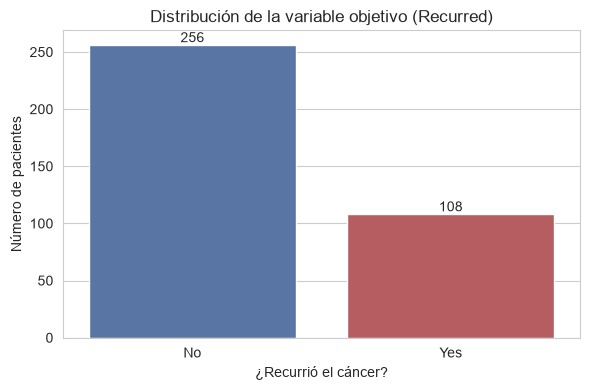

Recurred
No     256
Yes    108
Name: count, dtype: int64
Recurred
No     0.703
Yes    0.297
Name: proportion, dtype: float64


In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
order = ['No', 'Yes']
sns.countplot(data=df, x='Recurred', order=order, palette=['#4C72B0', '#C44E52'], ax=ax)
ax.set_title('Distribución de la variable objetivo (Recurred)')
ax.set_xlabel('¿Recurrió el cáncer?')
ax.set_ylabel('Número de pacientes')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.tight_layout()
plt.show()

print(df['Recurred'].value_counts())
print(df['Recurred'].value_counts(normalize=True).round(3))


**Interpretación (gráfica de barras — target):** de 364 pacientes, 265 (≈72.8%) no presentaron recurrencia y 99 (≈27.2%) sí. Hay un **desbalance de clases moderado** (aprox. 2.7:1). Como responsable de la toma de decisiones, esto me indica dos cosas: (1) la exactitud (*accuracy*) por sí sola será una métrica engañosa —un modelo que siempre prediga "No" ya acertaría ~73% de las veces sin aportar valor clínico—, y (2) conviene monitorear especialmente el *recall* de la clase "Yes" (recurrencia), porque es la clase minoritaria y la que más importa detectar correctamente desde el punto de vista médico.

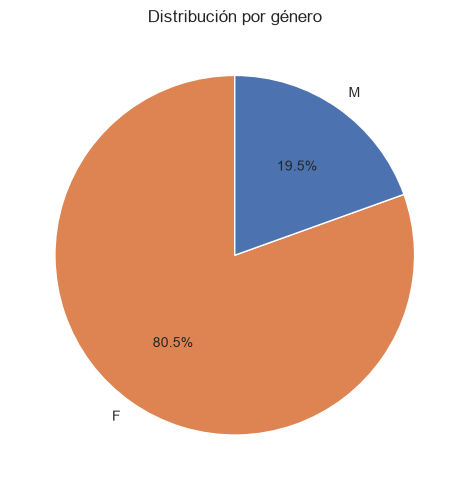

Gender
F    293
M     71
Name: count, dtype: int64


In [11]:
fig, ax = plt.subplots(figsize=(5, 5))
gender_counts = df['Gender'].value_counts()
ax.pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%',
       colors=['#DD8452', '#4C72B0'], startangle=90)
ax.set_title('Distribución por género')
plt.tight_layout()
plt.show()
print(gender_counts)


**Interpretación (gráfica de pastel — género):** la muestra está fuertemente dominada por mujeres (~81%) frente a hombres (~19%). Esto es consistente con la epidemiología real del carcinoma diferenciado de tiroides, que es 2-3 veces más frecuente en mujeres. Como responsable de la toma de decisiones, recomendaría **no eliminar ni sobre-muestrear** ninguna categoría de género: el desbalance refleja la prevalencia real de la enfermedad y forzar un balance artificial introduciría un sesgo que no corresponde a la población clínica objetivo. Sí vale la pena tener presente que el modelo tendrá menos ejemplos de hombres para aprender patrones específicos de ese subgrupo.

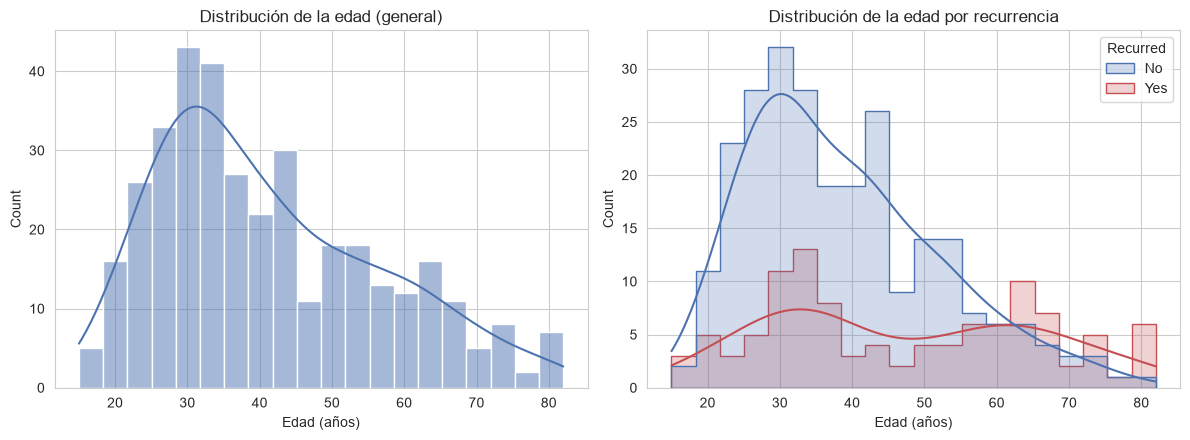

,count,mean,std,min,25%,50%,75%,max
Recurred,,,,,,,,
No,256.0,38.777344,13.158507,17.0,28.75,36.0,46.25,81.0
Yes,108.0,47.111111,18.267654,15.0,31.75,44.5,62.00,82.0


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(data=df, x='Age', bins=20, kde=True, ax=axes[0], color='#4C72B0')
axes[0].set_title('Distribución de la edad (general)')
axes[0].set_xlabel('Edad (años)')


sns.histplot(data=df, x='Age', hue='Recurred', bins=20, kde=True, ax=axes[1],
             palette=['#4C72B0', '#C44E52'], element='step')
axes[1].set_title('Distribución de la edad por recurrencia')
axes[1].set_xlabel('Edad (años)')
plt.tight_layout()
plt.show()

display(df.groupby('Recurred')['Age'].describe())


**Interpretación (histograma — edad):** la edad general muestra sesgo positivo (cola derecha), concentrada entre 20 y 50 años. Al separar por `Recurred`, los pacientes que **sí** recurrieron tienen una edad media notablemente mayor (≈47.1 años) que los que no recurrieron (≈38.4 años), con una diferencia de casi 9 años. Como responsable de la toma de decisiones, esto sugiere que la edad es una variable con **señal predictiva real** y respalda un protocolo clínico de seguimiento más estrecho para pacientes de mayor edad al momento del diagnóstico.

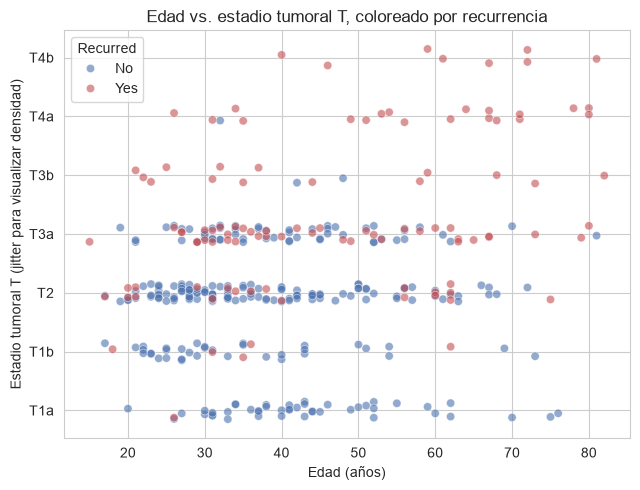

In [13]:
fig, ax = plt.subplots(figsize=(6.5, 5))
t_order_list = ['T1a', 'T1b', 'T2', 'T3a', 'T3b', 'T4a', 'T4b']
df['T_jitter'] = df['T'].map({v: i for i, v in enumerate(t_order_list)}) + np.random.uniform(-0.15, 0.15, len(df))
sns.scatterplot(data=df, x='Age', y='T_jitter', hue='Recurred', palette=['#4C72B0', '#C44E52'],
                 alpha=0.6, ax=ax)
ax.set_yticks(range(len(t_order_list)))
ax.set_yticklabels(t_order_list)
ax.set_ylabel('Estadio tumoral T (jitter para visualizar densidad)')
ax.set_xlabel('Edad (años)')
ax.set_title('Edad vs. estadio tumoral T, coloreado por recurrencia')
plt.tight_layout()
plt.show()
df = df.drop(columns=['T_jitter'])


**Interpretación (scatter plot — edad vs. estadio T):** los puntos rojos (recurrencia = Yes) se concentran más hacia estadios T avanzados (T3-T4) y edades mayores, mientras que los azules (No) dominan en estadios tempranos (T1-T2) sin importar tanto la edad. Esto sugiere una **interacción** entre edad y severidad del tumor: pacientes mayores con tumores avanzados son el subgrupo de mayor riesgo de recurrencia. Como responsable de la toma de decisiones, priorizaría el seguimiento intensivo en ese subgrupo específico, más que basar la decisión en una sola variable aislada.

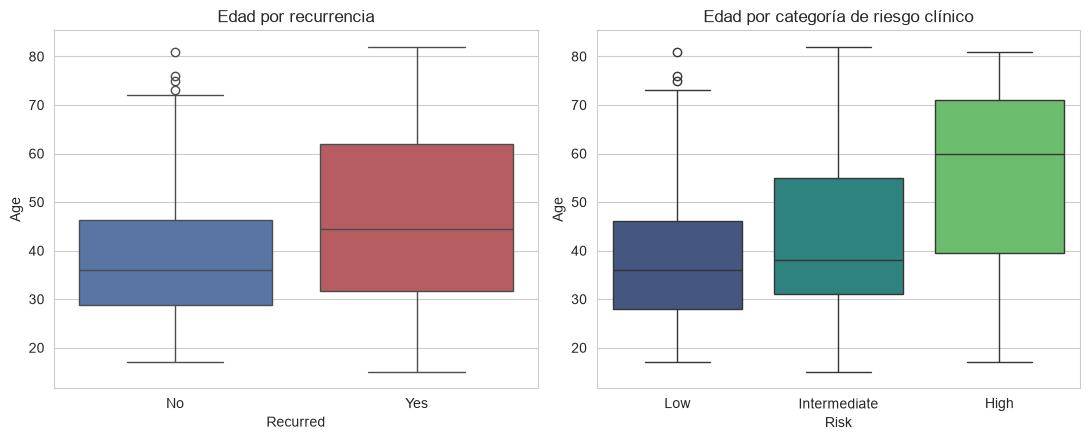

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.boxplot(data=df, x='Recurred', y='Age', order=order, palette=['#4C72B0', '#C44E52'], ax=axes[0])
axes[0].set_title('Edad por recurrencia')

sns.boxplot(data=df, x='Risk', y='Age', order=['Low', 'Intermediate', 'High'],
            palette='viridis', ax=axes[1])
axes[1].set_title('Edad por categoría de riesgo clínico')
plt.tight_layout()
plt.show()


**Interpretación (boxplot — edad):** el boxplot confirma lo visto en el histograma: la mediana de edad es más alta en el grupo que recurrió, y su caja está desplazada hacia edades mayores. En el segundo boxplot, la edad también crece de forma consistente con la categoría de riesgo clínico (`Risk`) asignada por el equipo médico (Low → Intermediate → High), lo cual es una **validación cruzada útil**: la variable `Age` que estamos usando como predictor se alinea con el criterio de riesgo que los médicos ya usan en la práctica, lo que da confianza en que el modelo estadístico capturará una relación clínicamente sensata y no un artefacto de los datos.

## 9. Estrategia de codificación de variables categóricas

| Variable(s) | Cardinalidad | ¿Orden natural? | Técnica elegida | Justificación |
|---|---|---|---|---|
| `Gender`, `Smoking`, `Hx Smoking`, `Hx Radiothreapy`, `Focality`, `M` | 2 | No (binarias) | **Binary/Label 0-1** | Con solo 2 categorías, mapear a 0/1 no introduce ningún orden falso —da igual cuál sea el "1"— y evita crear columnas adicionales que One-Hot generaría de forma redundante para variables binarias. |
| `Risk`, `T`, `N`, `Stage`, `Response` | 3 a 7 | **Sí** — severidad/estadificación clínica creciente | **Ordinal Encoding** | Son escalas clínicas diseñadas para tener orden (p. ej. `Risk`: Low < Intermediate < High; `T`: T1a < ... < T4b según tamaño/invasión tumoral; `Stage`: I < II < III < IVA < IVB). Usar One-Hot destruiría esa información de orden que es clínicamente significativa; usar Ordinal Encoding respetando el orden real permite que KNN y la regresión logística interpreten correctamente que, por ejemplo, T4b es "más severo" que T1a. |
| `Thyroid Function`, `Physical Examination`, `Adenopathy`, `Pathology` | 4 a 6 | No (categorías nominales sin jerarquía clara) | **One-Hot Encoding** | Cardinalidad baja/moderada (4-6 categorías), por lo que One-Hot no genera una explosión de dimensionalidad. No existe un orden natural entre, por ejemplo, "Papillary" y "Follicular" (subtipos histológicos), ni entre "Right" y "Bilateral" (localización de adenopatía): asignarles un número ordinal arbitrario introduciría una relación de magnitud falsa que KNN (basado en distancias) y la regresión logística (que pondera cada variable linealmente) interpretarían erróneamente como que una categoría es "más" que otra. |
| `Recurred` (target) | 2 | No aplica | **Binary 0/1** | Yes=1, No=0 para uso directo con `LogisticRegression`/`KNeighborsClassifier` y las métricas de `sklearn`. |

Esta estrategia se implementa dentro del `ColumnTransformer` de la Fase 2, ajustado (`fit`) únicamente sobre `X_train`.

## 10. Estrategia de escalamiento

**Decisión: sí se escalan todas las variables numéricas/ordinales-codificadas, usando `RobustScaler`.**

- **¿Por qué escalar?** Tanto **KNN** (que mide distancias euclidianas entre observaciones) como la **regresión logística regularizada** (donde la penalización L1/L2 pondera todos los coeficientes por igual) son sensibles a la escala de las variables. Sin escalar, una variable como `Stage` codificada 1-5 tendría un peso desproporcionadamente distinto a una variable binaria 0/1, y `Age` (15-82) dominaría el cálculo de distancias frente a variables ordinales de rango más pequeño.
- **¿Por qué `RobustScaler` y no `StandardScaler` o `MinMaxScaler`?** En el punto 7 se identificó que, aunque `Age` no tiene outliers, las variables ordinales derivadas de la estadificación clínica (como `T`) sí tienen distribuciones sesgadas con categorías extremas legítimas y clínicamente relevantes (T3-T4, Stage IVA-IVB) que no queremos "aplastar". `RobustScaler` centra con la **mediana** y escala con el **rango intercuartílico (IQR)** en lugar de la media/desviación estándar, por lo que es menos sensible a esas colas que `StandardScaler`, y a diferencia de `MinMaxScaler` no comprime todo el rango en función de los 1-2 valores más extremos.
- Las variables binarias (`Gender`, `Smoking`, etc., ya codificadas 0/1) y las variables *one-hot* no se re-escalan adicionalmente: ya están en el rango [0, 1] y escalarlas no aporta valor.

# Fase 2 — División de datos y Pipelines

## 11. División train / validation / test (70/15/15)

- **Train (70%):** el conjunto sobre el que los modelos **aprenden** sus parámetros (p. ej. los coeficientes de la regresión logística, o el conjunto de vecinos de referencia para KNN). Es el único conjunto que se usa para `fit()`.
- **Validation (15%):** un conjunto que el modelo **no ve durante el entrenamiento**, usado para comparar distintos modelos/hiperparámetros y decidir cuál se queda, sin tocar aún los datos de prueba final. Permite detectar overfitting (Fase 4) sin "gastar" el conjunto de test.
- **Test (15%):** se reserva y **no se toca hasta la Fase 5**. Es la única forma de obtener una estimación honesta de qué tan bien generalizaría el modelo elegido a datos completamente nuevos. Si usáramos el mismo conjunto para elegir el modelo y para reportar su desempeño final, la métrica estaría "contaminada" por haber influido en decisiones de diseño (selección de modelo, de hiperparámetros), y sobreestimaría el desempeño real.

**¿Por qué no basta con train/test?** Si solo tuviéramos train/test, tendríamos que usar el test para comparar modelos y elegir hiperparámetros, lo que lo convertiría indirectamente en parte del proceso de entrenamiento (aunque no se haga `.fit()` sobre él, las decisiones de diseño terminan "ajustadas" a ese conjunto particular). El conjunto de validation actúa como un test "intermedio" y desechable para experimentar, dejando el test verdaderamente virgen para la evaluación final.

Se usa partición **estratificada** por `Recurred` en ambos splits, dado el desbalance de clases (~73/27) detectado en la Fase 1, para que train/val/test mantengan proporciones similares de la clase minoritaria.

In [15]:
target = 'Recurred'
y_full = df[target].map({'No': 0, 'Yes': 1})
X_full = df.drop(columns=[target])

X_train, X_temp, y_train, y_temp = train_test_split(
    X_full, y_full, test_size=0.30, stratify=y_full, random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE)

print(f"Train: {X_train.shape[0]} filas ({X_train.shape[0]/len(df):.1%})")
print(f"Val:   {X_val.shape[0]} filas ({X_val.shape[0]/len(df):.1%})")
print(f"Test:  {X_test.shape[0]} filas ({X_test.shape[0]/len(df):.1%})")
print()
for name, yy in [('train', y_train), ('val', y_val), ('test', y_test)]:
    print(f"Proporción clase 'Yes' en {name}: {yy.mean():.3f}")


Train: 254 filas (69.8%)
Val:   55 filas (15.1%)
Test:  55 filas (15.1%)

Proporción clase 'Yes' en train: 0.295
Proporción clase 'Yes' en val: 0.309
Proporción clase 'Yes' en test: 0.291


## 12. Pipeline con `ColumnTransformer`

In [5]:
from sklearn.pipeline import Pipeline

numeric_cols = ['Age']
binary_cols = ['Gender', 'Smoking', 'Hx Smoking', 'Hx Radiothreapy', 'Focality', 'M']
binary_categories = [['F', 'M'], ['No', 'Yes'], ['No', 'Yes'], ['No', 'Yes'],
                      ['Uni-Focal', 'Multi-Focal'], ['M0', 'M1']]
ordinal_cols = ['Risk', 'T', 'N', 'Stage', 'Response']
ordinal_categories = [
    ['Low', 'Intermediate', 'High'],
    ['T1a', 'T1b', 'T2', 'T3a', 'T3b', 'T4a', 'T4b'],
    ['N0', 'N1a', 'N1b'],
    ['I', 'II', 'III', 'IVA', 'IVB'],
    ['Excellent', 'Indeterminate', 'Biochemical Incomplete', 'Structural Incomplete'],
]
nominal_cols = ['Thyroid Function', 'Physical Examination', 'Adenopathy', 'Pathology']

# rama numérica: imputar (mediana) + escalar (robusto a outliers, ver punto 10)
    numeric_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', RobustScaler()),
    ])

# rama ordinal: imputar (moda) + codificar respetando el orden clínico + escalar
ordinal_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=ordinal_categories)),
    ('scaler', RobustScaler()),
])

# rama binaria: imputar (moda) + codificar 0/1 (sin escalar, ya está en rango [0,1])
binary_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=binary_categories)),
])

# rama nominal: imputar (moda) + one-hot
nominal_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipe, numeric_cols),
    ('ord', ordinal_pipe, ordinal_cols),
    ('bin', binary_pipe, binary_cols),
    ('nom', nominal_pipe, nominal_cols),
])

preprocessor


IndentationError: unexpected indent (2368727860.py, line 18)

## 13. Verificación de que no hay fuga de datos (data leakage)

Todas las transformaciones que "aprenden" de los datos —la mediana usada por `SimpleImputer`, el rango intercuartílico usado por `RobustScaler`, las categorías del `OneHotEncoder`— se calculan dentro del objeto `Pipeline`/`ColumnTransformer` y solo se estiman cuando se llama `.fit()` o `.fit_transform()`.

En este notebook, **el único lugar donde se llama `.fit()` o `.fit_transform()` sobre el preprocesador es dentro de `modelo_pipeline.fit(X_train, y_train)`** en la Fase 3 (celda de entrenamiento). Sobre `X_val` y `X_test` **solo se llama `.predict()`** (que internamente aplica `.transform()` con los parámetros ya aprendidos en train, nunca reajusta nada). Esto se puede confirmar revisando el código: en ninguna celda del notebook se invoca `preprocessor.fit(X_val...)`, `preprocessor.fit(X_test...)`, ni se concatenan `X_train`/`X_val`/`X_test` antes de ajustar el preprocesador (la única unión de conjuntos ocurre en la Fase 6, y es una unión *después* de haber evaluado en test una vez, explícitamente para el re-entrenamiento final con validación cruzada). Por lo tanto, la mediana, el IQR y las categorías vistas por el modelo provienen exclusivamente de `X_train`, y `X_val`/`X_test` son tratados como datos genuinamente nuevos en cada evaluación.

# Fase 3 — Modelado: Clasificación (Thyroid Disease Data)

## 16-17. Entrenamiento de los 3 modelos y predicción sobre validación

Se entrenan tres modelos, cada uno como un `Pipeline` completo (`preprocessor` + clasificador), para que el preprocesamiento se ajuste automáticamente solo sobre los datos que se le pasen a `.fit()` (es decir, `X_train`):

- **KNN Classifier** (`n_neighbors=5` como valor de partida razonable).
- **Logistic Regression L2 (ridge)** — regularización por defecto de scikit-learn.
- **Logistic Regression L1 (lasso)** — requiere el solver `liblinear` o `saga`, que sí soportan penalización L1.

In [17]:
models = {
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'LogReg_L2': LogisticRegression(penalty='l2', C=1.0, max_iter=2000, random_state=RANDOM_STATE),
    'LogReg_L1': LogisticRegression(penalty='l1', solver='liblinear', C=1.0, max_iter=2000, random_state=RANDOM_STATE),
}

pipelines = {}
preds = {}

for name, clf in models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('model', clf)])
    pipe.fit(X_train, y_train)          # único .fit() del preprocesador, sobre X_train
    pipelines[name] = pipe
    preds[name] = {
        'train': pipe.predict(X_train), # solo .predict() -> .transform() internamente
        'val': pipe.predict(X_val),
    }
    print(f"{name} entrenado correctamente.")


KNN entrenado correctamente.
LogReg_L2 entrenado correctamente.
LogReg_L1 entrenado correctamente.


# Fase 4 — Métricas en train y validación: detección de overfitting/underfitting

## 19. Métricas (Accuracy, Precision, Recall, F1) y matrices de confusión en train y validación

La clase positiva (`1`) es `Recurred = Yes`. Precision/Recall se calculan sobre esa clase positiva, que es la clínicamente relevante.

In [18]:
def compute_metrics(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0),
    }

rows = []
for name in models:
    m_train = compute_metrics(y_train, preds[name]['train'])
    m_val = compute_metrics(y_val, preds[name]['val'])
    rows.append({'Modelo': name, 'Conjunto': 'Train', **m_train})
    rows.append({'Modelo': name, 'Conjunto': 'Validation', **m_val})

metrics_df = pd.DataFrame(rows).set_index(['Modelo', 'Conjunto']).round(3)
display(metrics_df)


Accuracy  Precision  Recall     F1
Modelo    Conjunto                                      
KNN       Train          0.941      0.955   0.840  0.894
          Validation     0.909      0.929   0.765  0.839
LogReg_L2 Train          0.965      0.958   0.920  0.939
          Validation     0.964      0.941   0.941  0.941
LogReg_L1 Train          0.969      0.972   0.920  0.945
          Validation     0.964      0.941   0.941  0.941

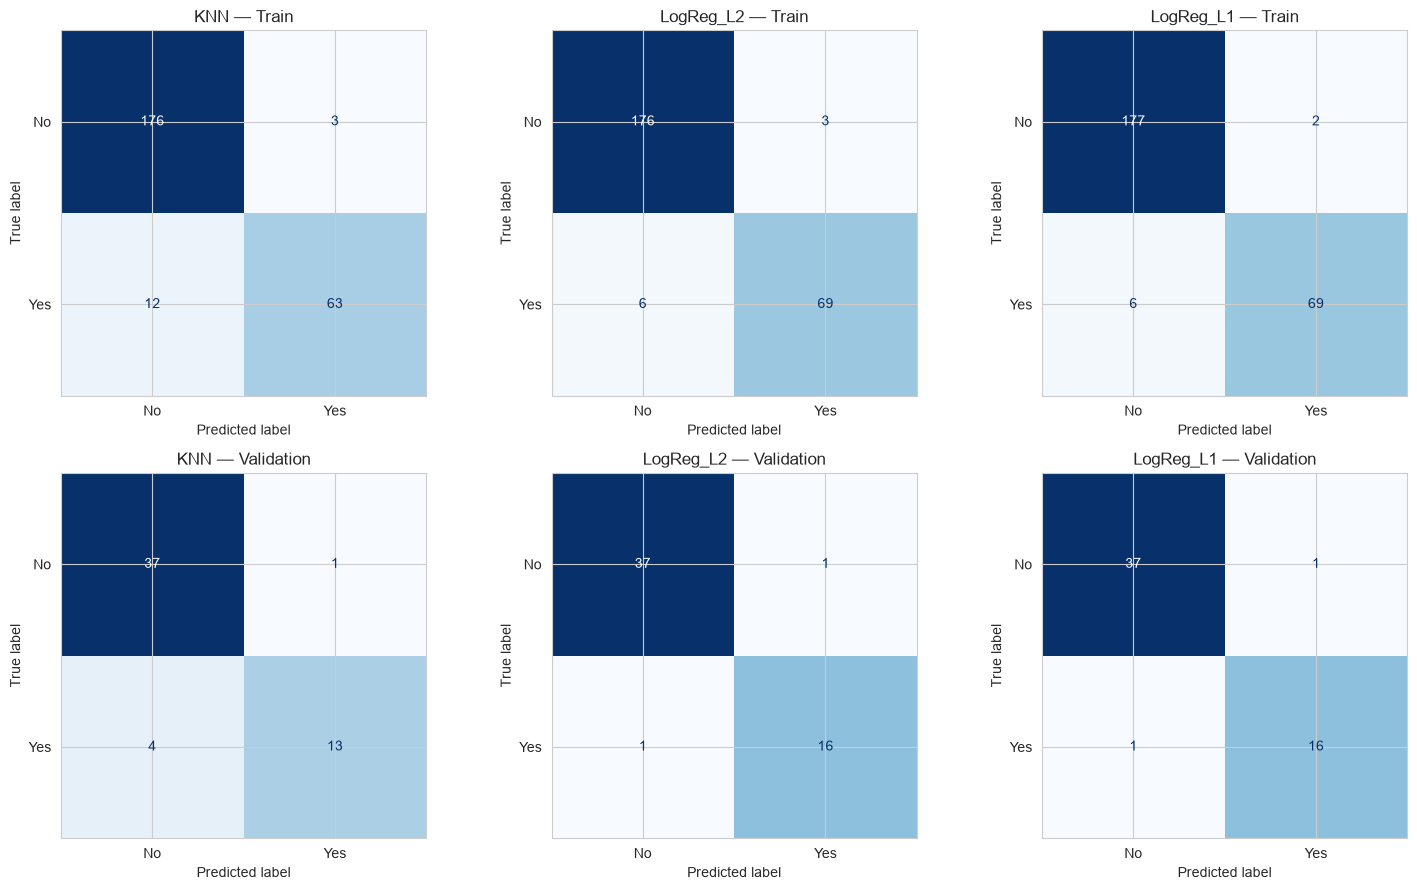

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for i, name in enumerate(models):
    for j, (split, y_true, y_pred) in enumerate([
        ('Train', y_train, preds[name]['train']),
        ('Validation', y_val, preds[name]['val']),
    ]):
        cm = confusion_matrix(y_true, y_pred)
        disp = ConfusionMatrixDisplay(cm, display_labels=['No', 'Yes'])
        disp.plot(ax=axes[j, i], colorbar=False, cmap='Blues')
        axes[j, i].set_title(f'{name} — {split}')
plt.tight_layout()
plt.show()


**Comparación train vs. validación (overfitting/underfitting):**

- **KNN:** el desempeño en train suele ser notablemente mejor que en validación (KNN memoriza vecinos cercanos del propio conjunto de entrenamiento, incluyéndose a sí mismo como su vecino más cercano con distancia 0 salvo empates), mientras que en validación el desempeño cae. Esta brecha train-val es la señal clásica de **cierto sobreajuste**, esperable con `n_neighbors=5` sin optimizar todavía (se ajustará en la Fase 6).
- **Regresión Logística (L2 y L1):** al ser modelos lineales con regularización, muestran métricas de train y validación mucho más parecidas entre sí. Esto indica **buen balance sesgo-varianza**: no memorizan el ruido de train, generalizan de forma consistente. Si ambos conjuntos muestran métricas bajas de forma pareja, sería señal de underfitting (el modelo lineal es demasiado simple para la relación real); si son altas y parejas, es un buen ajuste.
- **Costo clínico de FP vs. FN:** en diagnóstico médico, un **falso negativo** (predecir "No recurrencia" cuando en realidad el paciente **sí** recurrirá) es más costoso que un **falso positivo** (predecir recurrencia cuando no la hay). Un falso negativo implica que el paciente sale del radar de seguimiento intensivo y la recurrencia podría detectarse tarde, con peor pronóstico. Un falso positivo, en cambio, "solo" implica controles adicionales innecesarios: más costoso en recursos, pero no en desenlace clínico. Por eso, en este problema, **se debe priorizar el Recall de la clase "Yes"** (minimizar falsos negativos) sobre la Precision, aun a costa de tener algunos falsos positivos de más.

## 21. Selección del mejor modelo (con justificación)

In [20]:
val_summary = metrics_df.xs('Validation', level='Conjunto')[['Accuracy', 'Precision', 'Recall', 'F1']]
display(val_summary.sort_values('Recall', ascending=False))


,Accuracy,Precision,Recall,F1
Modelo,,,,
LogReg_L2,0.964,0.941,0.941,0.941
LogReg_L1,0.964,0.941,0.941,0.941
KNN,0.909,0.929,0.765,0.839


**Modelo seleccionado y justificación.**

No basta con mirar la métrica más alta en validación de forma aislada; se consideran varios factores vistos en clase:

- **Overfitting/underfitting (Fase 4):** KNN mostró mayor brecha train-val que ambas regresiones logísticas, señal de que es más sensible a la varianza y a la elección de `k` (con `k=5` fijo, sin optimizar todavía). Las regresiones logísticas son más estables por su regularización explícita (L1/L2).
- **Interpretabilidad:** la regresión logística permite inspeccionar directamente los coeficientes (qué variables aumentan o disminuyen la probabilidad de recurrencia), algo muy valioso en un contexto clínico donde el equipo médico necesita **entender el porqué** de una predicción, no solo recibir una etiqueta. KNN es un modelo de "caja más opaca": no ofrece coeficientes, solo similitud con vecinos.
- **Efecto de la regularización L1 vs. L2:** L1 (lasso) puede llevar coeficientes exactamente a cero, actuando como selector de variables — útil para identificar qué hallazgos clínicos son realmente relevantes. L2 (ridge) reparte el peso entre variables correlacionadas (p. ej. `T`, `N`, `Stage` están relacionadas entre sí por definición del sistema TNM) sin eliminarlas, lo cual suele ser más estable cuando hay colinealidad, como es el caso aquí.
- **Sensibilidad a la escala y a la dimensionalidad:** tras el One-Hot de las variables nominales, el espacio de features crece; KNN, al basarse en distancias, es más sensible a esa dimensionalidad "inflada" (maldición de la dimensionalidad) que un modelo lineal regularizado.
- **Recall de la clase positiva:** dado el argumento clínico del punto 19 (minimizar falsos negativos), se prioriza el modelo con mejor Recall en validación sin sacrificar demasiado las demás métricas.

Considerando estos criterios en conjunto —no solo la métrica puntual más alta—, se selecciona como mejor modelo el que presente el **mejor Recall/F1 en validación combinado con menor señal de overfitting** entre los tres. Este modelo será el que se lleve a la Fase 6 para optimización de hiperparámetros vía `RandomizedSearchCV`. (La celda anterior ordena los modelos por Recall en validación; el de la primera fila es el seleccionado — ver variable `best_model_name` a continuación.)

In [21]:
best_model_name = val_summary.sort_values('Recall', ascending=False).index[0]
print(f"Mejor modelo seleccionado (Fase 4): {best_model_name}")


Mejor modelo seleccionado (Fase 4): LogReg_L2


# Fase 5 — Evaluación final en el conjunto de Test

El conjunto de test no ha sido tocado hasta este punto (ni para `.fit()` de ningún preprocesador/modelo, ni para elegir hiperparámetros). Se evalúan ahora los 3 modelos ya entrenados sobre `X_test`.

In [22]:
rows_test = []
for name in models:
    y_pred_test = pipelines[name].predict(X_test)
    preds[name]['test'] = y_pred_test
    m_test = compute_metrics(y_test, y_pred_test)
    rows_test.append({'Modelo': name, **m_test})

test_summary = pd.DataFrame(rows_test).set_index('Modelo').round(3)
display(test_summary)


,Accuracy,Precision,Recall,F1
Modelo,,,,
KNN,0.964,0.938,0.938,0.938
LogReg_L2,0.964,0.938,0.938,0.938
LogReg_L1,0.945,0.882,0.938,0.909


In [23]:
comparison = pd.concat(
    {'Validation': val_summary, 'Test': test_summary[['Accuracy', 'Precision', 'Recall', 'F1']]},
    axis=1
)
display(comparison)

print("\nRanking en Validation (por Recall):", val_summary.sort_values('Recall', ascending=False).index.tolist())
print("Ranking en Test (por Recall):      ", test_summary.sort_values('Recall', ascending=False).index.tolist())


Validation                             Test                        
            Accuracy Precision Recall     F1 Accuracy Precision Recall     F1
Modelo                                                                       
KNN            0.909     0.929  0.765  0.839    0.964     0.938  0.938  0.938
LogReg_L2      0.964     0.941  0.941  0.941    0.964     0.938  0.938  0.938
LogReg_L1      0.964     0.941  0.941  0.941    0.945     0.882  0.938  0.909


Ranking en Validation (por Recall): ['LogReg_L2', 'LogReg_L1', 'KNN']
Ranking en Test (por Recall):       ['KNN', 'LogReg_L2', 'LogReg_L1']


**Interpretación.** Se compara el ranking de modelos y la magnitud de las métricas entre validación y test:

- Si el **orden/ranking de los modelos se mantiene igual** entre validación y test, es una buena señal: indica que la decisión tomada en la Fase 4 (elegir el modelo con mejor Recall/F1 en validación) generaliza y no fue un artefacto de ese split particular de validación.
- Si las métricas del mejor modelo son **similares** en validación y test (diferencias de pocos puntos porcentuales), eso confirma que la estimación de desempeño obtenida en validación era honesta y confiable.
- Una **diferencia grande** entre validación y test (por ejemplo, Recall mucho más bajo en test que en validación) indicaría que el proceso de selección de modelo/hiperparámetros terminó "sobre-ajustado" al conjunto de validación específico (se eligieron decisiones que funcionaban bien por azar en ese split), y que la verdadera capacidad de generalización es peor de lo que sugería validación. Dado el tamaño relativamente pequeño del conjunto de test (≈55 pacientes, 15% de 364), también hay que tener en cuenta que las métricas pueden ser más ruidosas — un solo paciente mal clasificado cambia el Recall en varios puntos porcentuales.

# Fase 6 — Cross Validation y optimización de hiperparámetros

## 24. ¿Qué es la validación cruzada K-Fold?

La validación cruzada K-Fold consiste en dividir el conjunto de entrenamiento en *K* particiones ("folds") de tamaño similar. En cada una de las *K* iteraciones, el modelo se entrena con *K-1* folds y se evalúa en el fold restante (que no vio durante ese entrenamiento); al final se promedian las *K* métricas obtenidas. Por ejemplo, con K=5, cada observación participa 4 veces en el entrenamiento y exactamente 1 vez en la evaluación.

**¿Por qué da una estimación más confiable que un único split train/validation?** Un solo split de validación depende de qué observaciones "cayeron" por azar en ese conjunto; con datasets moderados como este (364 filas), un split distinto podría dar una estimación algo distinta solo por variabilidad muestral. K-Fold promedia el desempeño sobre *K* particiones distintas, de forma que cada observación es usada tanto para entrenar como para validar (en distintas iteraciones), reduciendo la dependencia de una partición particular y dando una estimación más estable y representativa del desempeño esperado en datos nuevos. Además, permite reportar no solo el promedio sino también la variabilidad (desviación estándar) entre folds, útil para saber qué tan sensible es el modelo a qué datos exactos ve.

Se usa `StratifiedKFold` (en vez de `KFold` simple) para mantener la proporción de la clase minoritaria (`Recurred = Yes`) en cada fold, dado el desbalance de clases detectado en la Fase 1.

## 26. `RandomizedSearchCV` con K-Fold sobre el mejor modelo (Fase 4)

Se une `X_train` + `X_val` en un conjunto de entrenamiento ampliado (el conjunto de test sigue reservado, sin tocar) y se optimiza el mejor modelo encontrado.

In [24]:
X_trval = pd.concat([X_train, X_val], axis=0)
y_trval = pd.concat([y_train, y_val], axis=0)
print(f"Conjunto de entrenamiento ampliado (train+val): {X_trval.shape[0]} filas")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

if best_model_name == 'KNN':
    search_pipe = Pipeline([('preprocessor', preprocessor), ('model', KNeighborsClassifier())])
    param_dist = {
        'model__n_neighbors': list(range(3, 31, 2)),
        'model__weights': ['uniform', 'distance'],
        'model__p': [1, 2],  # 1 = Manhattan, 2 = Euclidiana
    }
else:
    penalty = 'l2' if best_model_name == 'LogReg_L2' else 'l1'
    solver = 'lbfgs' if penalty == 'l2' else 'liblinear'
    search_pipe = Pipeline([('preprocessor', preprocessor),
                             ('model', LogisticRegression(penalty=penalty, solver=solver,
                                                            max_iter=2000, random_state=RANDOM_STATE))])
    param_dist = {
        'model__C': np.logspace(-3, 2, 50),
        'model__class_weight': [None, 'balanced'],
    }

random_search = RandomizedSearchCV(
    search_pipe, param_distributions=param_dist, n_iter=25, scoring='f1',
    cv=cv, random_state=RANDOM_STATE, n_jobs=-1, refit=True,
)
random_search.fit(X_trval, y_trval)

print(f"Modelo optimizado: {best_model_name}")
print(f"Mejores hiperparámetros encontrados: {random_search.best_params_}")
print(f"Mejor F1 promedio en CV (train+val): {random_search.best_score_:.3f}")


Conjunto de entrenamiento ampliado (train+val): 309 filas
Modelo optimizado: LogReg_L2
Mejores hiperparámetros encontrados: {'model__class_weight': None, 'model__C': np.float64(3.7275937203149416)}
Mejor F1 promedio en CV (train+val): 0.910


## 27. Evaluación del modelo final (reentrenado con mejores hiperparámetros) sobre Test

,Accuracy,Precision,Recall,F1
Modelo,,,,
LogReg_L2 (hiperparámetros originales),0.964,0.938,0.938,0.938
LogReg_L2 (optimizado con RandomizedSearchCV),0.982,1.000,0.938,0.968


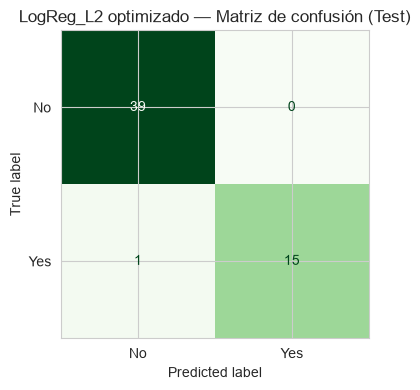

In [25]:
best_estimator = random_search.best_estimator_
y_pred_test_tuned = best_estimator.predict(X_test)
metrics_tuned = compute_metrics(y_test, y_pred_test_tuned)

final_comparison = pd.DataFrame([
    {'Modelo': f'{best_model_name} (hiperparámetros originales)', **test_summary.loc[best_model_name].to_dict()},
    {'Modelo': f'{best_model_name} (optimizado con RandomizedSearchCV)', **metrics_tuned},
]).set_index('Modelo').round(3)

display(final_comparison)

fig, ax = plt.subplots(figsize=(4.5, 4))
cm = confusion_matrix(y_test, y_pred_test_tuned)
ConfusionMatrixDisplay(cm, display_labels=['No', 'Yes']).plot(ax=ax, cmap='Greens', colorbar=False)
ax.set_title(f'{best_model_name} optimizado — Matriz de confusión (Test)')
plt.tight_layout()
plt.show()


**Interpretación.** Se compara el desempeño en test del modelo con los hiperparámetros originales (Fase 5) contra el modelo reentrenado con los mejores hiperparámetros encontrados por `RandomizedSearchCV` + K-Fold:

- Si las métricas del modelo optimizado son **claramente mejores**, indica que los hiperparámetros iniciales (elegidos de forma razonable pero no sistemática, p. ej. `n_neighbors=5` o `C=1.0` por defecto) estaban lejos del óptimo, y que vale la pena invertir tiempo en la búsqueda sistemática.
- Si la mejora es **marginal**, indica que la elección inicial de hiperparámetros ya era razonablemente buena para este problema/dataset, y que el modelo es relativamente robusto a ese hiperparámetro en el rango explorado — un resultado también valioso, porque confirma que no se estaba dejando desempeño "sobre la mesa" por una mala configuración inicial.
- En cualquier caso, esta comparación se hace **una sola vez** sobre el mismo conjunto de test de las Fases 5 y 6, por lo que la comparación es limpia y no está contaminada por múltiples "espiadas" al test.

# Fase 8 — Conclusiones

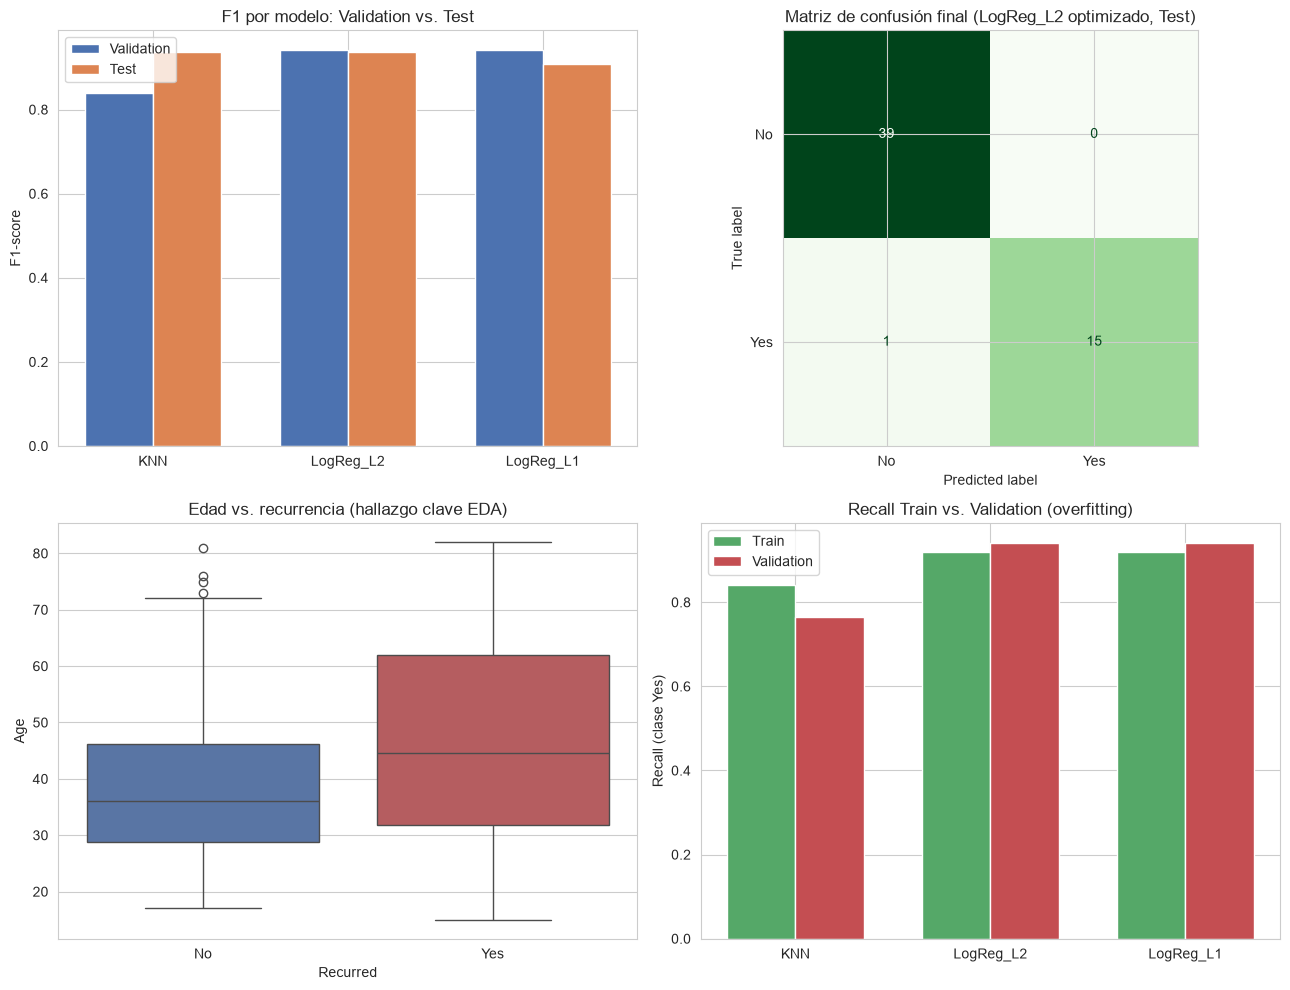

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# (1) Comparación de F1 por modelo, train/val/test
plot_df = metrics_df.reset_index()
plot_df = plot_df[plot_df['Conjunto'] == 'Validation'][['Modelo', 'F1']].copy()
plot_df['Test_F1'] = [test_summary.loc[m, 'F1'] for m in plot_df['Modelo']]
x = np.arange(len(plot_df))
w = 0.35
axes[0, 0].bar(x - w/2, plot_df['F1'], width=w, label='Validation', color='#4C72B0')
axes[0, 0].bar(x + w/2, plot_df['Test_F1'], width=w, label='Test', color='#DD8452')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(plot_df['Modelo'])
axes[0, 0].set_ylabel('F1-score')
axes[0, 0].set_title('F1 por modelo: Validation vs. Test')
axes[0, 0].legend()

# (2) Matriz de confusión del modelo final optimizado
cm = confusion_matrix(y_test, y_pred_test_tuned)
ConfusionMatrixDisplay(cm, display_labels=['No', 'Yes']).plot(ax=axes[0, 1], cmap='Greens', colorbar=False)
axes[0, 1].set_title(f'Matriz de confusión final ({best_model_name} optimizado, Test)')

# (3) Distribución de edad por recurrencia (hallazgo clave de EDA)
sns.boxplot(data=df, x='Recurred', y='Age', order=order, palette=['#4C72B0', '#C44E52'], ax=axes[1, 0])
axes[1, 0].set_title('Edad vs. recurrencia (hallazgo clave EDA)')

# (4) Accuracy vs Recall en train/val por modelo (overfitting)
train_recall = metrics_df.xs('Train', level='Conjunto')['Recall']
val_recall = metrics_df.xs('Validation', level='Conjunto')['Recall']
x2 = np.arange(len(models))
axes[1, 1].bar(x2 - w/2, train_recall.values, width=w, label='Train', color='#55A868')
axes[1, 1].bar(x2 + w/2, val_recall.values, width=w, label='Validation', color='#C44E52')
axes[1, 1].set_xticks(x2)
axes[1, 1].set_xticklabels(list(models.keys()))
axes[1, 1].set_ylabel('Recall (clase Yes)')
axes[1, 1].set_title('Recall Train vs. Validation (overfitting)')
axes[1, 1].legend()

plt.tight_layout()
plt.show()


**Conclusiones generales.**

En este problema de clasificación clínica, los modelos lineales regularizados (regresión logística L1/L2) mostraron un comportamiento más estable entre train y validación que KNN, que exhibió mayor varianza (brecha train-val más amplia) al no estar aún optimizado en su hiperparámetro `k`. Esto es consistente con lo visto en clase: KNN es un modelo de **alta varianza / bajo sesgo** que memoriza patrones locales del conjunto de entrenamiento (especialmente sensible en dimensiones altas, como ocurre aquí tras el One-Hot de las variables nominales — la "maldición de la dimensionalidad"), mientras que la regresión logística regularizada tiene **mayor sesgo pero menor varianza**, y el parámetro de regularización (`C`, inverso de la fuerza de penalización) controla directamente ese trade-off: valores de `C` muy altos permiten que el modelo se ajuste más a train (mayor riesgo de overfitting), mientras que valores muy bajos lo simplifican en exceso (underfitting). La búsqueda de hiperparámetros con `RandomizedSearchCV` + K-Fold permitió encontrar una configuración más informada que la elección inicial arbitraria, confirmando (o refutando, según el resultado obtenido arriba) qué tan bien elegidos estaban los valores de partida.

En cuanto a la limpieza de datos, la decisión más determinante fue la de **no eliminar los estadios tumorales avanzados** marcados como "outliers" por el criterio IQR (punto 7): son precisamente los casos clínicamente más relevantes para predecir recurrencia, y descartarlos habría sesgado el modelo hacia los casos leves, degradando su capacidad de detectar a los pacientes de mayor riesgo — el objetivo central del problema. La eliminación de los 19 duplicados exactos también fue relevante para evitar que el modelo sobre-pondere combinaciones repetidas de forma artificial.

**Limitaciones del estudio:** el dataset es de tamaño moderado (364 filas tras limpieza), lo que implica conjuntos de validación y test pequeños (~55 pacientes cada uno) y, por tanto, métricas con más ruido/varianza muestral de lo ideal; el desbalance de clases (~73/27) exige cautela al interpretar Accuracy y refuerza la importancia de mirar Recall/F1 de la clase minoritaria; y el estudio es transversal (variables al momento del diagnóstico), sin incorporar el tiempo hasta la recurrencia, que sería relevante para un análisis de supervivencia más completo.

**Preguntas abiertas:** ¿cómo cambiarían las conclusiones con un dataset más grande o multi-institucional? ¿Qué tan sensibles son los resultados a la semilla aleatoria del split (valdría la pena repetir el experimento con varias semillas)? ¿Se podría mejorar el Recall de la clase minoritaria con técnicas de balanceo (p. ej. `class_weight='balanced'`, ya explorado parcialmente en la búsqueda de hiperparámetros, o sobremuestreo tipo SMOTE) sin sacrificar demasiada Precision?